# Probabilistic Seasonal Influenza Forecasting

This notebook focuses on probabilistic forecasting, the last step after parameter inference via MCMC, performed in the notebook `02_parameters_inference.ipynb`.

The main goals of this notebook are:
- to propagate parameter uncertainty into future epidemic trajectories,
- to qualitatively visualize probabilistic forecasts of seasonal influenza.

## 1. Setup and environment

We load the required libraries and project modules.
The repository root is added to the Python path to enable local imports.

In [6]:
import sys
from pathlib import Path

# Add repository root to Python path
repo_root = Path().resolve().parent
sys.path.append(str(repo_root))

# Standard
import numpy as np
import pickle
import torch
from torch import nn, load

# Project modules
from src.models.sir_inn import NN
from src.forecasting.probabilistic_forecast import run_probabilistic_forecast_season, plot_probabilistic_forecasts_season

## 2. Probabilistic forecasting

In the previous notebook `02_parameters_inference.ipynb` we performed Bayesian parameter inference on the Influcast ILI observations using a rolling-window strategy.
At each epidemiological week, a short observation window is assimilated (i.e., rolling window of length `observation_window_size = 5`) and a Markov Chain Monte Carlo (MCMC) procedure is employed to infer the epidemiological parameters of the SIR-INN model.

Posterior samples of the SIR-based transition rates: the disease transmission rate $\beta$, the recovery rate $\gamma$, and the epidemic alignment time $\tau_0$ are now propagated forward through the SIR-INN to generate probabilistic forecasts. Relative prediction intervals and quantiles are computed to provide Uncertainty Quantification (UQ).

### 2.1 Load the pretrained SIR-INN model

In [7]:
# The model approximates the continuous-time SIR dynamics
activation = nn.Tanh
dimensions = [3, 16, 32, 16, 3]
sir_inn = NN(activation=activation, dimensions=dimensions)
sir_inn.load_state_dict(torch.load("../checkpoints_all/SIR-INN_pretrained.pth", map_location='cpu'))

sir_inn.eval()

NN(
  (stack): Sequential(
    (0): Linear(in_features=3, out_features=16, bias=True)
    (1): Tanh()
    (2): Linear(in_features=16, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): Tanh()
    (6): Linear(in_features=16, out_features=3, bias=True)
    (7): Sigmoid()
  )
)

### 2.2 Experimental setup

In [8]:
## From the experimental setup in the previous notebook
# Influenza season under study
season = '2023-2024'

# Folder of results
chains_dir = rf"../tmp_results/{season}/" 

#Type of priors
priors = 'uniform'

# Length of rolling window of observations (weeks)
observation_window_size=5

In [9]:
## Forecast horizon in weeks.
# Set to 4 for short-term forecasting (four weeks ahead)
# or to 10 for long-term forecasting (ten weeks ahead).
# This choice determines the forecast plots in Section 3.
forecast_window_size = 4 #4 or 10

### 2.3 Forecast step with SIR-INN

Select `fit=True` to visualize also the observation window probabilistic interpolation.

In [10]:
forecasts_sirinn = run_probabilistic_forecast_season(
    chains_dir=chains_dir,
    dt_train=observation_window_size,
    dt_forecast=observation_window_size + forecast_window_size,
    nsample=1000,
    priors=priors,
    pinn_model=sir_inn,      # Your trained PINN
    fit=False
)

print(f"Generated forecasts for {len(forecasts_sirinn)} time points")

Generated forecasts for 25 time points


## 3. Short- and long-term forecasts visualization

For each time window of observations, we visualize the predictive mean
together with 50% and 90% prediction intervals.
Observed incidence is shown for reference.

In [54]:
# Optional: reload previously saved forecasts to skip the inference step above
with open(chains_dir +rf"{priors}/forecast/forecast_results.pickle", "rb") as f:
    forecasts_sirinn = pickle.load(f)

In [11]:
# Select the grid size: number of subpanels to visualize.

size=3 #2 or 3 or 5

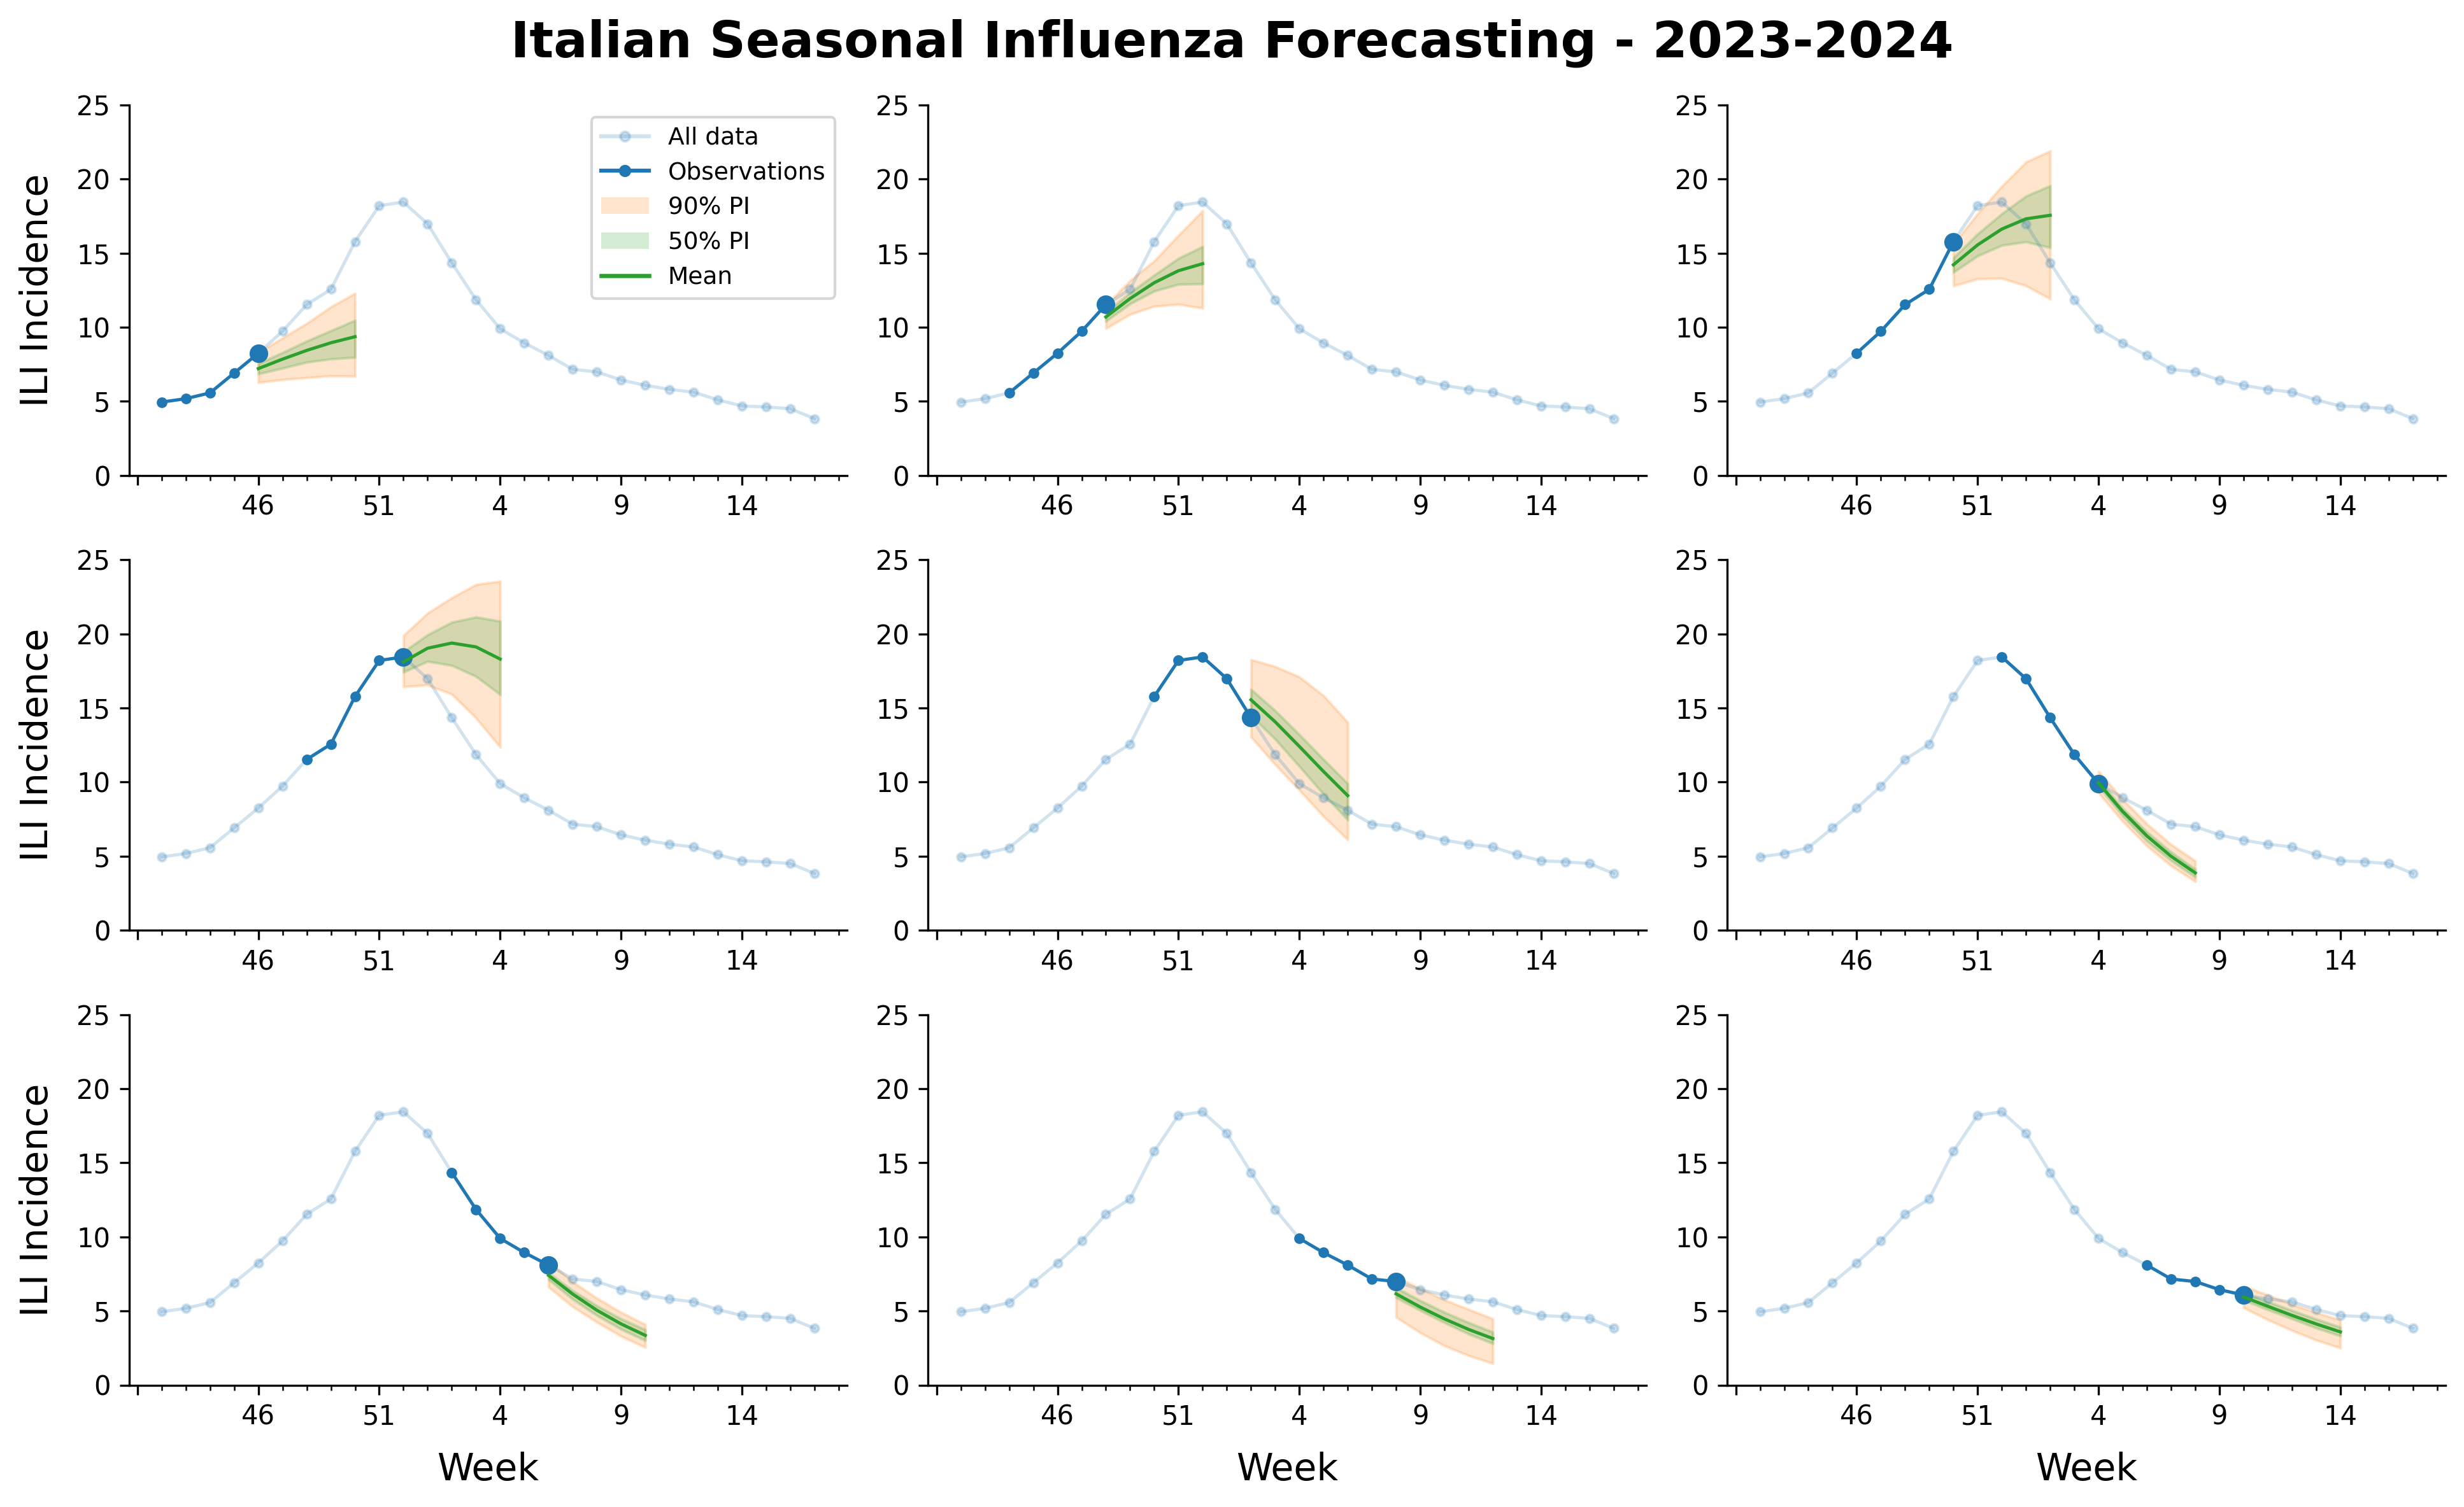

In [12]:
fig1 = plot_probabilistic_forecasts_season(
    forecasts=forecasts_sirinn,
    season=season,
    dt_train=observation_window_size,
    grid_size=size
)

fig1.savefig(f'../tmp_results/Plot/forecast/season_forecast_{season}_{size}.jpg', dpi=300, bbox_inches='tight')

## 4. Summary

Probabilistic forecasts have been generated for one influenza season using posterior samples from the MCMC inference step in `02_parameters_inference.ipynb`. To see the results related to another season, please make sure to run also the previous notebook with the other choice of `season`.

At each epidemiological week, the posterior distributions of $\beta$, $\gamma$, and $\tau_0$ are propagated forward through the pretrained SIR-INN to produce an ensemble of incidence trajectories. The 50% and 90% prediction intervals together with the posterior predictive mean are shown for each rolling window.

The plots above correspond to the selected `forecast_window_size`: use $4$ for short-term forecasting (four weeks ahead) or $10$ for long-term forecasting (ten weeks ahead). To reproduce the alternative horizon, re-run the notebook with the other value and update `grid_size` accordingly to better visualize the forecasts (we recommend a smaller grid size for the long-term forecasts).